In [22]:
import os
import sys
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# Add the script directory to path to import the library
# Assuming the notebook is in scripts/post_analysis and the lib is in the same folder
sys.path.append(os.getcwd())
import corner_detection_lib as cdl

# Define paths
# Adjust the relative path to point to the data directory
data_dir = os.path.abspath(os.path.join(os.getcwd(), '../run_files/batch_inputs/seq14'))
json_path = os.path.join(data_dir, 'step0.frame_data.json')
img_path = os.path.join(data_dir, 'step0.camera1.png')

print(f"Data Directory: {data_dir}")
print(f"JSON Path Exists: {os.path.exists(json_path)}")
print(f"Image Path Exists: {os.path.exists(img_path)}")

Data Directory: c:\Users\andrew.wf.ng\Scripts\FoundationStereo\scripts\run_files\batch_inputs\seq14
JSON Path Exists: True
Image Path Exists: True


Found 4 corners.
Camera Position: [130.464813, 34.99468, 78.59717]
Camera Rotation: [-0.0593963563, 0.9104934, -0.1631301, -0.3753167]
Intrinsics: fx=253.90621750000003, fy=253.90619999999998, cx=325.0, cy=200.0
Camera Forward Vector: [-0.66406795 -0.34164257 -0.66505196]
Corner 0: Dist=6.92m, Off-Axis=31.7°, Bearing=282.9°
Corner 1: Dist=16.65m, Off-Axis=16.7°, Bearing=0.7°
Corner 2: Dist=17.93m, Off-Axis=3.8°, Bearing=135.1°
Corner 3: Dist=9.59m, Off-Axis=35.3°, Bearing=209.7°


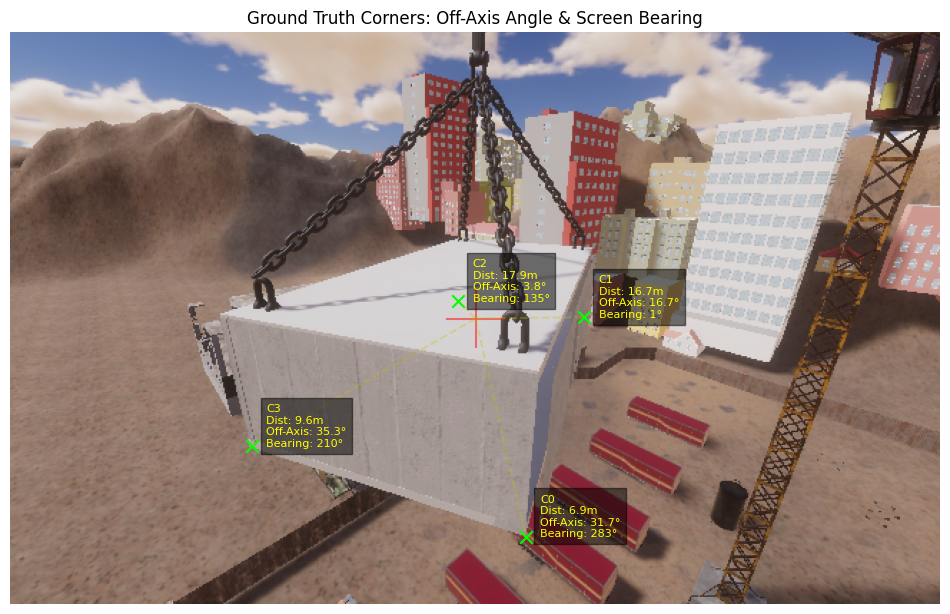

In [23]:
# Load Image
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Get Ground Truth Corners
gt_corners = cdl.find_ground_truth_corners(json_path)
if gt_corners is None:
    raise ValueError("Could not find ground truth corners in JSON")
print(f"Found {len(gt_corners)} corners.")

# Get Camera Transform
cam_pos, cam_rot = cdl.get_camera_transform(json_path)
if cam_pos is None:
    raise ValueError("Could not find camera transform in JSON")
print(f"Camera Position: {cam_pos}")
print(f"Camera Rotation: {cam_rot}")

# Get Intrinsics
fx, fy, cx, cy, _ = cdl.find_camera_intrinsics([data_dir])
print(f"Intrinsics: fx={fx}, fy={fy}, cx={cx}, cy={cy}")

# Calculations
cam_pos_np = np.array(cam_pos)
cam_rot_obj = R.from_quat(cam_rot) 
# Assuming Unity coordinate system: Z is forward
cam_forward = cam_rot_obj.apply(np.array([0, 0, 1]))

print(f"Camera Forward Vector: {cam_forward}")

# Prepare Plot
plt.figure(figsize=(12, 10))
plt.imshow(img_rgb)
plt.title("Ground Truth Corners: Off-Axis Angle & Screen Bearing")

# Draw center crosshair
plt.plot([cx-20, cx+20], [cy, cy], 'r-', alpha=0.5)
plt.plot([cx, cx], [cy-20, cy+20], 'r-', alpha=0.5)

for i, corner in enumerate(gt_corners):
    # Vector from Camera to Corner
    corner_vec = corner - cam_pos_np
    dist = np.linalg.norm(corner_vec)
    
    # 1. Off-Axis Angle (3D angle from center)
    corner_vec_norm = corner_vec / dist
    dot_prod = np.dot(corner_vec_norm, cam_forward)
    off_axis_angle_rad = np.arccos(np.clip(dot_prod, -1.0, 1.0))
    off_axis_angle_deg = np.degrees(off_axis_angle_rad)
    
    # Project to Screen
    # Transform to Camera Space
    inv_rot = cam_rot_obj.inv()
    p_cam = inv_rot.apply(corner_vec)
    
    # Check if point is in front of camera
    if p_cam[2] <= 0:
        print(f"Corner {i}: Behind camera (z={p_cam[2]:.2f})")
        continue
        
    # Projection
    u = (p_cam[0] * fx / p_cam[2]) + cx
    v = cy - (p_cam[1] * fy / p_cam[2])
    
    # 2. Screen Bearing (2D direction on image)
    # Calculate vector from center (cx, cy) to point (u, v)
    dx = u - cx
    dy = cy - v  # Invert Y because image Y is down, but we want standard math angle (Up is positive)
    bearing_deg = np.degrees(np.arctan2(dy, dx))
    if bearing_deg < 0:
        bearing_deg += 360
    
    print(f"Corner {i}: Dist={dist:.2f}m, Off-Axis={off_axis_angle_deg:.1f}°, Bearing={bearing_deg:.1f}°")
    
    plt.scatter(u, v, c='lime', s=80, marker='x')
    # Draw line to center to visualize bearing
    plt.plot([cx, u], [cy, v], 'y--', alpha=0.3)
    
    label = f"C{i}\nDist: {dist:.1f}m\nOff-Axis: {off_axis_angle_deg:.1f}°\nBearing: {bearing_deg:.0f}°"
    plt.text(u+10, v, label, color='yellow', fontsize=8, bbox=dict(facecolor='black', alpha=0.5))

plt.axis('off')
plt.show()